### EDA — `flights.csv`

Este notebook faz uma exploração dos dados com:
- Estatísticas descritivas (numéricas e categóricas)
- Visualizações para gerar insights (atrasos, cancelamentos, sazonalidade, companhias, aeroportos e horários)
- Tratamento de valores ausentes de forma adequada (especialmente campos dependentes de `CANCELLED`/`DIVERTED`)


In [1]:
from __future__ import annotations

from pathlib import Path
import warnings
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


In [2]:
from pathlib import Path
import pandas as pd

# Lê os CSVs a partir do repositório.
# Aceita duas estruturas comuns:
# - na raiz: ./flights.csv, ./airports.csv, ./airlines.csv
# - em pasta: ./data/flights.csv, ./data/airports.csv, ./data/airlines.csv

CANDIDATE_DIRS = [Path("."), Path("data")]


def pick_path(filename: str) -> Path:
    for d in CANDIDATE_DIRS:
        p = d / filename
        if p.exists():
            return p
    return CANDIDATE_DIRS[0] / filename


FLIGHTS_PATH = pick_path("flights.csv")
AIRPORTS_PATH = pick_path("airports.csv")
AIRLINES_PATH = pick_path("airlines.csv")

assert FLIGHTS_PATH.exists(), f"Arquivo não encontrado: {FLIGHTS_PATH.resolve()}"

airports = pd.read_csv(AIRPORTS_PATH) if AIRPORTS_PATH.exists() else None
airlines = pd.read_csv(AIRLINES_PATH) if AIRLINES_PATH.exists() else None

(FLIGHTS_PATH, AIRPORTS_PATH.exists(), AIRLINES_PATH.exists())

(PosixPath('flights.csv'), False, False)

In [3]:
DELAY_CAUSE_COLS = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY",
]

TIME_HHMM_COLS = [
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_TIME",
    "WHEELS_OFF",
    "WHEELS_ON",
    "SCHEDULED_ARRIVAL",
    "ARRIVAL_TIME",
]


def hhmm_to_minutes(x: object) -> float:
    """Converte HHMM (ex: 5, '0005', 2354) em minutos desde 00:00.

    Retorna NaN quando não for possível converter.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan

    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan

    # garante 4 dígitos (ex: '5' -> '0005')
    s = s.zfill(4)
    if not s.isdigit() or len(s) != 4:
        return np.nan

    hh = int(s[:2])
    mm = int(s[2:])
    if not (0 <= hh <= 23 and 0 <= mm <= 59):
        return np.nan
    return hh * 60 + mm


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["scheduled_dep_min"] = df["SCHEDULED_DEPARTURE"].map(hhmm_to_minutes)
    df["scheduled_dep_hour"] = (df["scheduled_dep_min"] // 60).astype("Int64")

    df["scheduled_arr_min"] = df["SCHEDULED_ARRIVAL"].map(hhmm_to_minutes)
    df["scheduled_arr_hour"] = (df["scheduled_arr_min"] // 60).astype("Int64")
    return df


def clean_flights(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # padroniza strings vazias como ausentes
    obj_cols = df.select_dtypes(include=["object", "string"]).columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].replace({"": pd.NA})

    # flags
    for c in ["CANCELLED", "DIVERTED"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype("Int8")

    not_cancelled = (df["CANCELLED"] == 0) if "CANCELLED" in df.columns else pd.Series(True, index=df.index)

    # causas de atraso: quando o voo ocorreu, NaN -> 0 ("não houve causa registrada")
    present_delay_cols = [c for c in DELAY_CAUSE_COLS if c in df.columns]
    if present_delay_cols:
        df.loc[not_cancelled, present_delay_cols] = df.loc[not_cancelled, present_delay_cols].apply(
            pd.to_numeric, errors="coerce"
        ).fillna(0)

    # motivo de cancelamento: preencher quando não cancelado
    if "CANCELLATION_REASON" in df.columns and "CANCELLED" in df.columns:
        df.loc[not_cancelled & df["CANCELLATION_REASON"].isna(), "CANCELLATION_REASON"] = "NOT_CANCELLED"
        df.loc[(~not_cancelled) & df["CANCELLATION_REASON"].isna(), "CANCELLATION_REASON"] = "UNKNOWN"

    # números
    num_like = [
        "YEAR",
        "MONTH",
        "DAY",
        "DAY_OF_WEEK",
        "DISTANCE",
        "DEPARTURE_DELAY",
        "ARRIVAL_DELAY",
        "TAXI_OUT",
        "TAXI_IN",
        "AIR_TIME",
        "ELAPSED_TIME",
        "SCHEDULED_TIME",
    ]
    for c in [x for x in num_like if x in df.columns]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # data (quando disponível)
    if all(c in df.columns for c in ["YEAR", "MONTH", "DAY"]):
        df["date"] = pd.to_datetime(
            {"year": df["YEAR"], "month": df["MONTH"], "day": df["DAY"]}, errors="coerce"
        )

    df = add_time_features(df)
    return df


def load_sample(
    path: Path,
    chunksize: int = 250_000,
    frac_per_chunk: float = 0.03,
    max_rows: int = 400_000,
    seed: int = 42,
) -> pd.DataFrame:
    """Amostra aproximada do CSV (boa para gráficos sem estourar memória)."""
    rng = np.random.default_rng(seed)
    samples: list[pd.DataFrame] = []

    for i, chunk in enumerate(pd.read_csv(path, chunksize=chunksize)):
        # amostra pequena por chunk para reduzir viés temporal
        s = chunk.sample(frac=frac_per_chunk, random_state=int(rng.integers(0, 2**31 - 1)))
        samples.append(s)

        if sum(len(x) for x in samples) >= max_rows:
            break

    df = pd.concat(samples, ignore_index=True)
    if len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=seed).reset_index(drop=True)

    return clean_flights(df)


sample = load_sample(FLIGHTS_PATH)
sample.shape

(174572, 36)

In [4]:
display(sample.head(3))

print("Linhas (amostra):", len(sample))
print("Colunas:", sample.columns.tolist())

# tipos e ausentes
missing = (
    sample.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_%")
    .to_frame()
)
missing.head(15)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,date,scheduled_dep_min,scheduled_dep_hour,scheduled_arr_min,scheduled_arr_hour
0,2015,1,13,2,WN,2963,N740SW,MDW,DCA,1050,NaN,NaN,NaN,NaN,105.0,NaN,NaN,601,NaN,NaN,1335,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN,2015-01-13,650,10,815,13
1,2015,1,2,5,DL,1922,N816DN,LAS,DTW,600,600.0,0.0,15.0,615.0,233.0,218.0,196.0,1749,1231.0,7.0,1253,1238.0,-15.0,0,0,NOT_CANCELLED,0.0,0.0,0.0,0.0,0.0,2015-01-02,360,6,773,12
2,2015,1,13,2,NK,230,N626NK,FLL,ATL,2145,2204.0,19.0,15.0,2219.0,107.0,112.0,90.0,581,2349.0,7.0,2332,2356.0,24.0,0,0,NOT_CANCELLED,5.0,0.0,19.0,0.0,0.0,2015-01-13,1305,21,1412,23


Linhas (amostra): 174572
Colunas: ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'date', 'scheduled_dep_min', 'scheduled_dep_hour', 'scheduled_arr_min', 'scheduled_arr_hour']


,missing_%
ARRIVAL_DELAY,1.821025
ELAPSED_TIME,1.821025
AIR_TIME,1.821025
ARRIVAL_TIME,1.584447
TAXI_IN,1.584447
WHEELS_ON,1.584447
SECURITY_DELAY,1.532892
LATE_AIRCRAFT_DELAY,1.532892
AIRLINE_DELAY,1.532892
AIR_SYSTEM_DELAY,1.532892


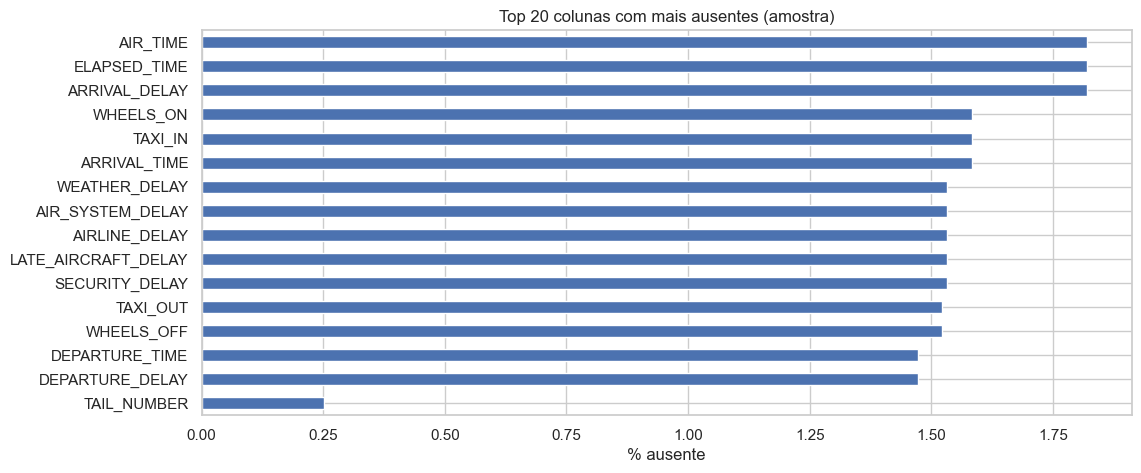

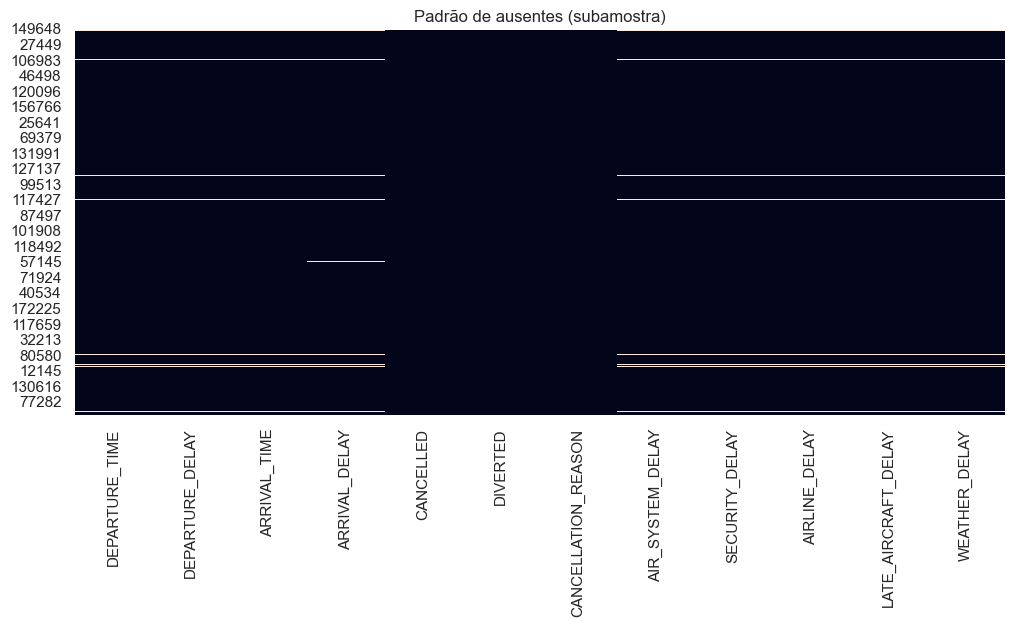

In [5]:
top_missing = missing[missing["missing_%"] > 0].head(20).sort_values("missing_%")
ax = top_missing.plot(kind="barh", legend=False)
ax.set_title("Top 20 colunas com mais ausentes (amostra)")
ax.set_xlabel("% ausente")
plt.show()

# heatmap (subconjunto para legibilidade)
cols_for_heatmap = [
    "DEPARTURE_TIME",
    "DEPARTURE_DELAY",
    "ARRIVAL_TIME",
    "ARRIVAL_DELAY",
    "CANCELLED",
    "DIVERTED",
    "CANCELLATION_REASON",
    *[c for c in DELAY_CAUSE_COLS if c in sample.columns],
]
cols_for_heatmap = [c for c in cols_for_heatmap if c in sample.columns]

sns.heatmap(sample[cols_for_heatmap].isna().sample(n=min(3000, len(sample)), random_state=42), cbar=False)
plt.title("Padrão de ausentes (subamostra)")
plt.show()

In [6]:
num_cols = sample.select_dtypes(include=["number"]).columns
cat_cols = [c for c in sample.columns if c not in num_cols]

sample[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T.sort_values("count")

,count,mean,std,min,1%,5%,50%,95%,99%,max
ARRIVAL_DELAY,171393.0,4.351747,39.472515,-79.0,-34.0,-25.0,-5.0,66.0,165.0,1554.0
AIR_TIME,171393.0,113.467388,72.206167,8.0,23.0,34.0,94.0,272.0,337.0,655.0
ELAPSED_TIME,171393.0,136.945459,74.161853,18.0,41.0,54.0,118.0,298.0,368.0,688.0
TAXI_IN,171806.0,7.430445,5.630796,1.0,2.0,3.0,6.0,16.0,30.0,170.0
ARRIVAL_TIME,171806.0,1480.850989,525.310687,1.0,29.0,658.0,1516.0,2248.0,2343.0,2400.0
WHEELS_ON,171806.0,1475.396727,521.36842,1.0,33.0,658.0,1512.0,2244.0,2341.0,2400.0
LATE_AIRCRAFT_DELAY,171896.0,4.363051,20.735051,0.0,0.0,0.0,0.0,27.0,104.0,808.0
SECURITY_DELAY,171896.0,0.013875,0.825895,0.0,0.0,0.0,0.0,0.0,0.0,133.0
WEATHER_DELAY,171896.0,0.538779,8.229257,0.0,0.0,0.0,0.0,0.0,7.0,689.0
AIR_SYSTEM_DELAY,171896.0,2.471558,12.926212,0.0,0.0,0.0,0.0,16.0,52.0,680.0


In [7]:
def top_value_counts(df: pd.DataFrame, col: str, n: int = 10) -> pd.DataFrame:
    vc = df[col].value_counts(dropna=False).head(n)
    out = vc.to_frame("count")
    out["pct"] = (out["count"] / len(df) * 100).round(2)
    return out

for c in ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "CANCELLATION_REASON"]:
    if c in sample.columns:
        display(pd.DataFrame({c: [c]}))
        display(top_value_counts(sample, c, n=12))

,AIRLINE
0,AIRLINE


,count,pct
AIRLINE,,
WN,37869,21.69
DL,26285,15.06
AA,21877,12.53
OO,17353,9.94
EV,17088,9.79
UA,15512,8.89
MQ,8931,5.12
B6,8066,4.62
US,6116,3.50


,ORIGIN_AIRPORT
0,ORIGIN_AIRPORT


,count,pct
ORIGIN_AIRPORT,,
ATL,10250,5.87
ORD,8502,4.87
DFW,7303,4.18
DEN,5814,3.33
LAX,5696,3.26
IAH,4510,2.58
PHX,4498,2.58
SFO,4442,2.54
LAS,4169,2.39


,DESTINATION_AIRPORT
0,DESTINATION_AIRPORT


,count,pct
DESTINATION_AIRPORT,,
ATL,10399,5.96
ORD,8638,4.95
DFW,7229,4.14
DEN,5971,3.42
LAX,5667,3.25
SFO,4440,2.54
PHX,4431,2.54
IAH,4314,2.47
LAS,3934,2.25


,CANCELLATION_REASON
0,CANCELLATION_REASON


,count,pct
CANCELLATION_REASON,,
NOT_CANCELLED,171896,98.47
B,1484,0.85
A,736,0.42
C,456,0.26


In [8]:
overall = {
    "cancelled_%": float(sample["CANCELLED"].mean() * 100) if "CANCELLED" in sample.columns else np.nan,
    "diverted_%": float(sample["DIVERTED"].mean() * 100) if "DIVERTED" in sample.columns else np.nan,
}
overall

{'cancelled_%': 1.532891872694361, 'diverted_%': 0.28813326306624204}

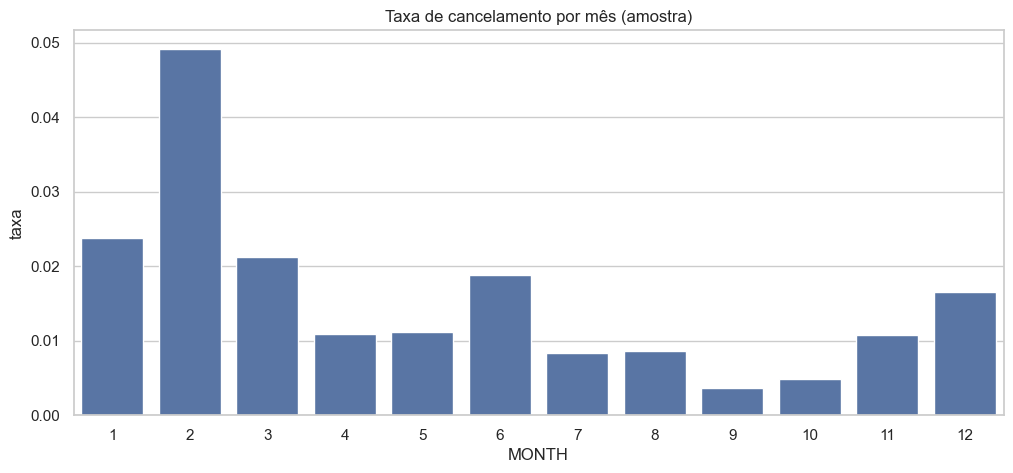

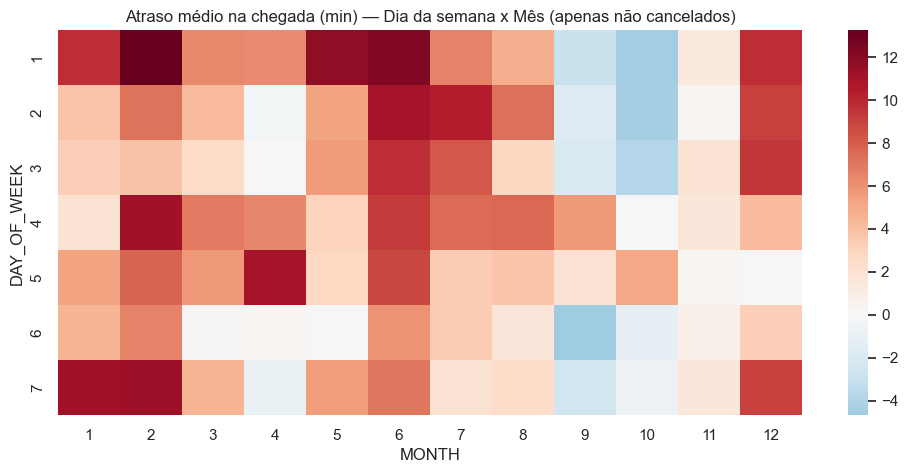

In [9]:
if "MONTH" in sample.columns and "CANCELLED" in sample.columns:
    by_month = (
        sample.groupby("MONTH", dropna=False)
        .agg(cancel_rate=("CANCELLED", "mean"), n=("CANCELLED", "size"))
        .reset_index()
        .sort_values("MONTH")
    )

    ax = sns.barplot(data=by_month, x="MONTH", y="cancel_rate")
    ax.set_title("Taxa de cancelamento por mês (amostra)")
    ax.set_ylabel("taxa")
    plt.show()

if all(c in sample.columns for c in ["MONTH", "DAY_OF_WEEK", "ARRIVAL_DELAY", "CANCELLED"]):
    active = sample[sample["CANCELLED"] == 0].copy()
    piv = active.pivot_table(index="DAY_OF_WEEK", columns="MONTH", values="ARRIVAL_DELAY", aggfunc="mean")
    sns.heatmap(piv, cmap="RdBu_r", center=0)
    plt.title("Atraso médio na chegada (min) — Dia da semana x Mês (apenas não cancelados)")
    plt.show()

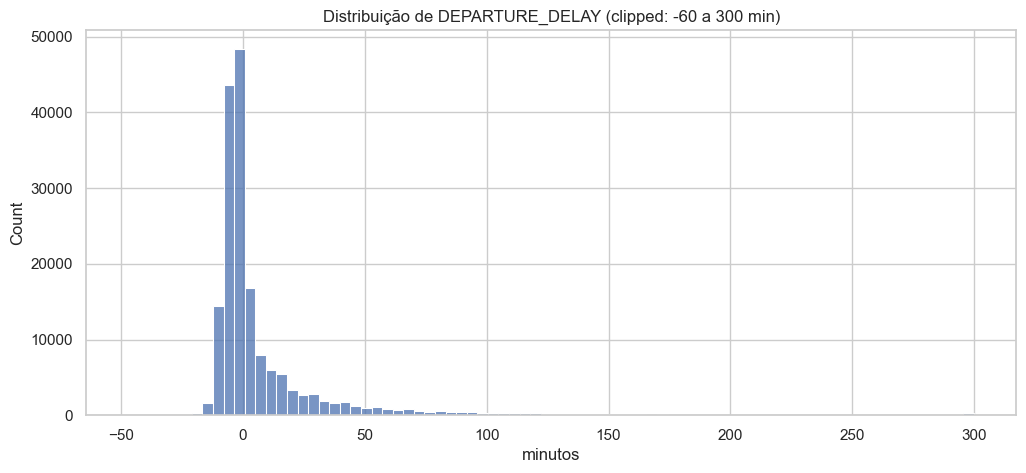

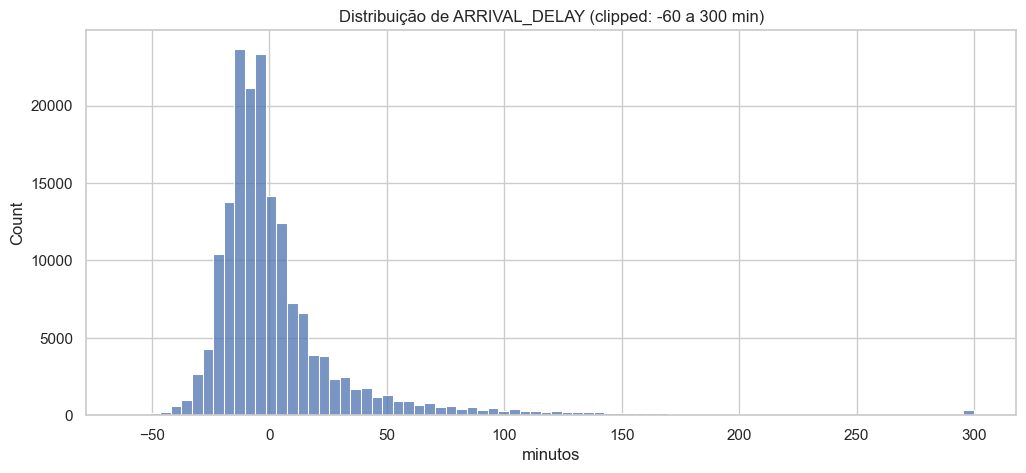

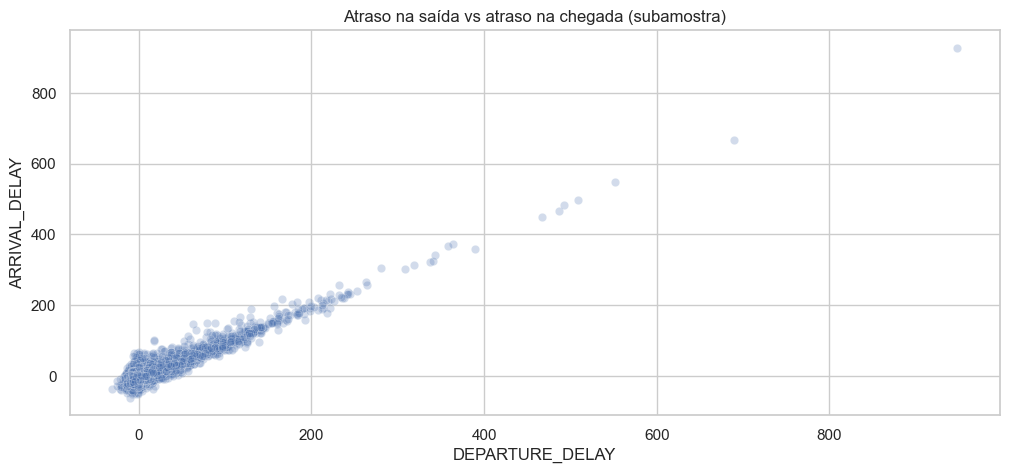

In [10]:
active = sample[sample.get("CANCELLED", 0) == 0].copy()

for col in ["DEPARTURE_DELAY", "ARRIVAL_DELAY"]:
    if col in active.columns:
        x = active[col].dropna().clip(lower=-60, upper=300)
        sns.histplot(x, bins=80)
        plt.title(f"Distribuição de {col} (clipped: -60 a 300 min)")
        plt.xlabel("minutos")
        plt.show()

if all(c in active.columns for c in ["DEPARTURE_DELAY", "ARRIVAL_DELAY"]):
    sns.scatterplot(
        data=active.sample(n=min(8000, len(active)), random_state=42),
        x="DEPARTURE_DELAY",
        y="ARRIVAL_DELAY",
        alpha=0.25,
    )
    plt.title("Atraso na saída vs atraso na chegada (subamostra)")
    plt.show()

,AIRLINE,flights,cancel_rate,mean_arr_delay,p90_arr_delay
1,AS,5114,0.004889,-1.095050,20.0
3,DL,26285,0.004451,-0.346865,21.0
6,HA,2373,0.002528,2.149386,17.0
0,AA,21877,0.014444,3.469182,35.0
11,US,6116,0.020438,3.766745,30.0
13,WN,37869,0.013467,4.328500,33.0
12,VX,1834,0.005453,4.429593,38.0
10,UA,15512,0.012829,5.174278,41.0
7,MQ,8931,0.051394,5.752546,44.0
9,OO,17353,0.016712,6.050661,37.0


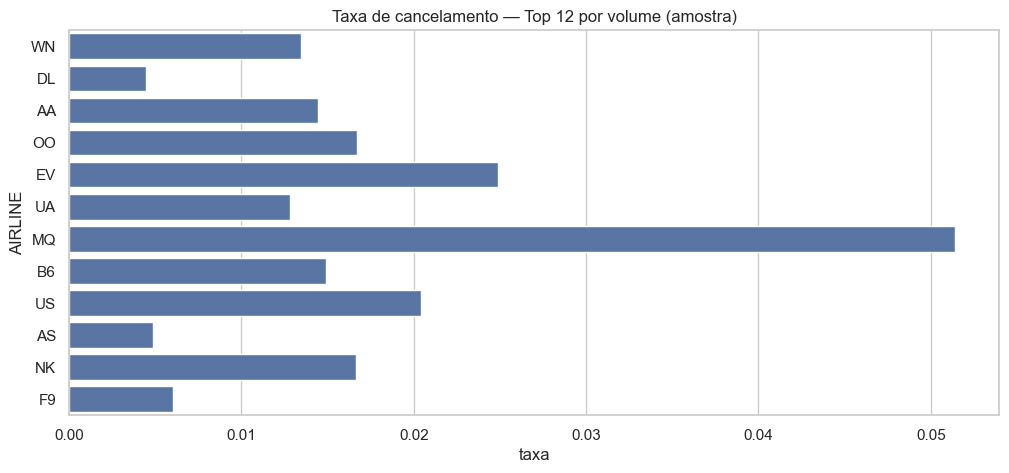

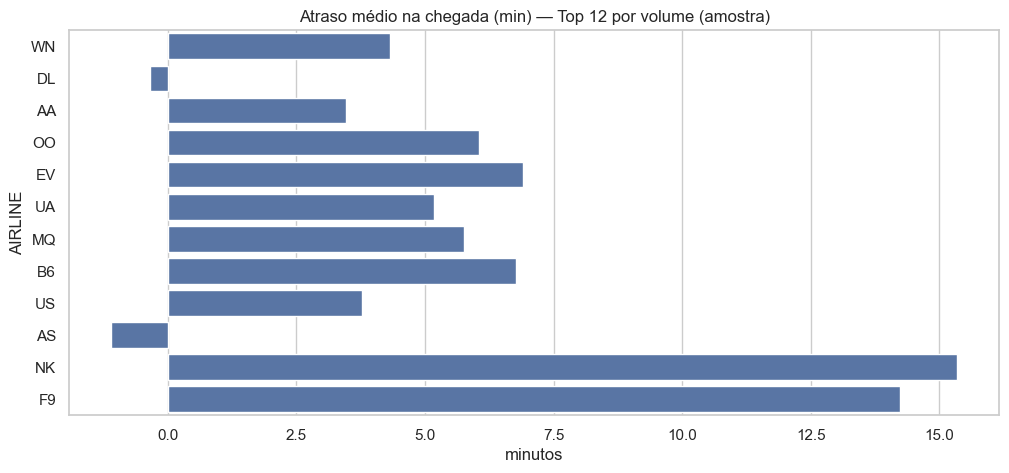

In [11]:
if "AIRLINE" in sample.columns:
    airline_metrics = (
        sample.assign(is_active=(sample.get("CANCELLED", 0) == 0).astype(int))
        .groupby("AIRLINE")
        .agg(
            flights=("AIRLINE", "size"),
            cancel_rate=("CANCELLED", "mean"),
            mean_arr_delay=("ARRIVAL_DELAY", "mean"),
            p90_arr_delay=("ARRIVAL_DELAY", lambda s: np.nanpercentile(s.dropna(), 90) if s.notna().any() else np.nan),
        )
        .reset_index()
    )

    airline_metrics = airline_metrics[airline_metrics["flights"] >= 500].sort_values("mean_arr_delay")

    if airlines is not None and set(["IATA_CODE", "AIRLINE"]).issubset(airlines.columns):
        airline_metrics = airline_metrics.merge(
            airlines.rename(columns={"IATA_CODE": "AIRLINE", "AIRLINE": "AIRLINE_NAME"}),
            on="AIRLINE",
            how="left",
        )

    display(airline_metrics.tail(15))

    top = airline_metrics.sort_values("flights", ascending=False).head(12)
    ax = sns.barplot(data=top, y=("AIRLINE_NAME" if "AIRLINE_NAME" in top.columns else "AIRLINE"), x="cancel_rate")
    ax.set_title("Taxa de cancelamento — Top 12 por volume (amostra)")
    ax.set_xlabel("taxa")
    plt.show()

    ax = sns.barplot(data=top, y=("AIRLINE_NAME" if "AIRLINE_NAME" in top.columns else "AIRLINE"), x="mean_arr_delay")
    ax.set_title("Atraso médio na chegada (min) — Top 12 por volume (amostra)")
    ax.set_xlabel("minutos")
    plt.show()

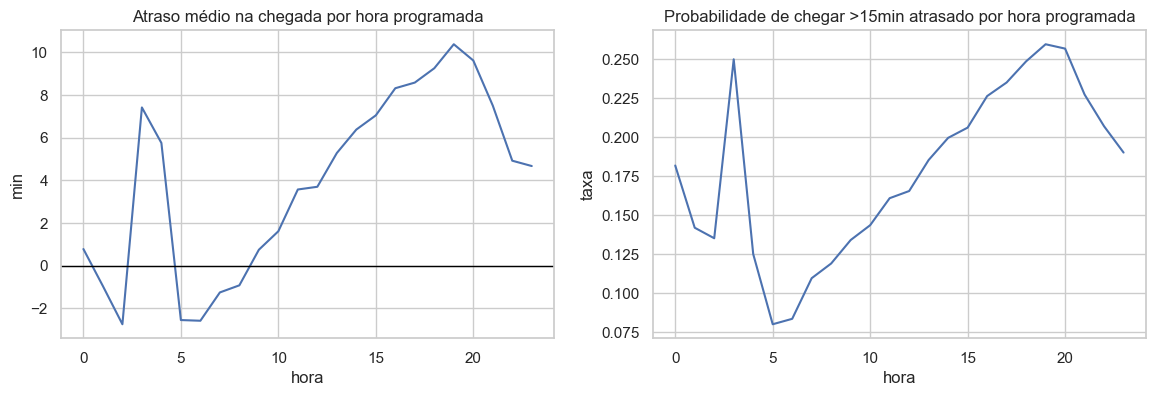

In [12]:
if all(c in active.columns for c in ["scheduled_dep_hour", "ARRIVAL_DELAY"]):
    hour_metrics = (
        active.dropna(subset=["scheduled_dep_hour"]).assign(late15=(active["ARRIVAL_DELAY"] > 15).astype(int))
        .groupby("scheduled_dep_hour")
        .agg(
            flights=("ARRIVAL_DELAY", "size"),
            mean_arr_delay=("ARRIVAL_DELAY", "mean"),
            late15_rate=("late15", "mean"),
        )
        .reset_index()
        .sort_values("scheduled_dep_hour")
    )

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    sns.lineplot(data=hour_metrics, x="scheduled_dep_hour", y="mean_arr_delay", ax=ax[0])
    ax[0].axhline(0, color="black", linewidth=1)
    ax[0].set_title("Atraso médio na chegada por hora programada")
    ax[0].set_xlabel("hora")
    ax[0].set_ylabel("min")

    sns.lineplot(data=hour_metrics, x="scheduled_dep_hour", y="late15_rate", ax=ax[1])
    ax[1].set_title("Probabilidade de chegar >15min atrasado por hora programada")
    ax[1].set_xlabel("hora")
    ax[1].set_ylabel("taxa")

    plt.show()

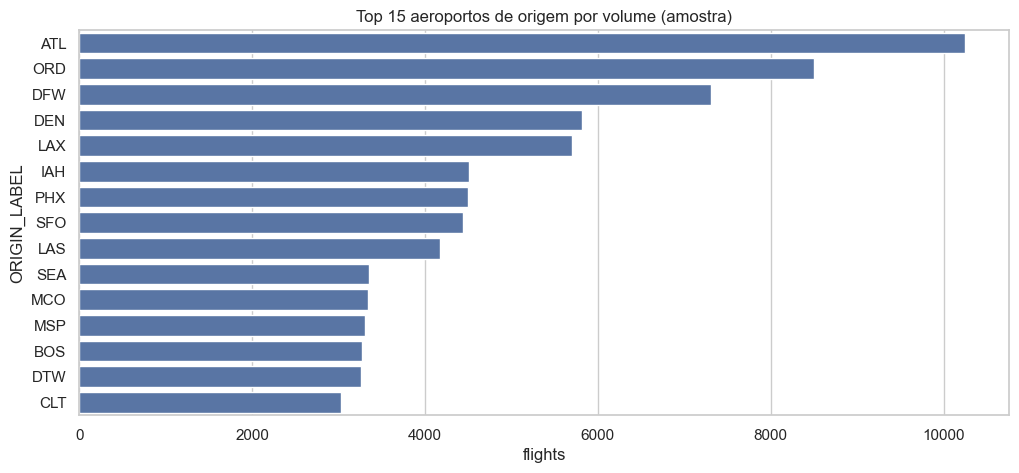

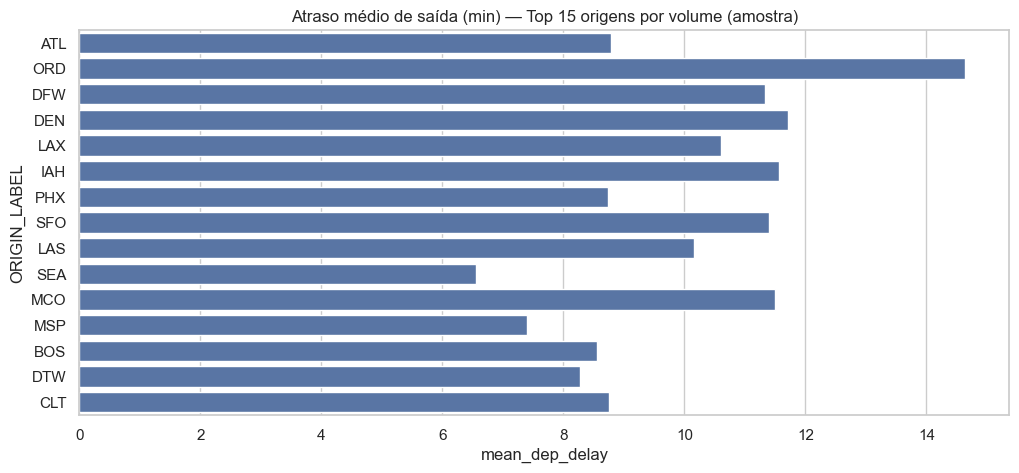

In [13]:
if "ORIGIN_AIRPORT" in sample.columns:
    origin_metrics = (
        sample.groupby("ORIGIN_AIRPORT")
        .agg(
            flights=("ORIGIN_AIRPORT", "size"),
            cancel_rate=("CANCELLED", "mean"),
            mean_dep_delay=("DEPARTURE_DELAY", "mean"),
            mean_arr_delay=("ARRIVAL_DELAY", "mean"),
        )
        .reset_index()
    )

    if airports is not None and set(["IATA_CODE", "AIRPORT", "CITY", "STATE"]).issubset(airports.columns):
        origin_metrics = origin_metrics.merge(
            airports[["IATA_CODE", "AIRPORT", "CITY", "STATE"]].rename(columns={"IATA_CODE": "ORIGIN_AIRPORT"}),
            on="ORIGIN_AIRPORT",
            how="left",
        )
        origin_metrics["ORIGIN_LABEL"] = origin_metrics.apply(
            lambda r: f"{r['ORIGIN_AIRPORT']} — {r['CITY']}, {r['STATE']}", axis=1
        )
    else:
        origin_metrics["ORIGIN_LABEL"] = origin_metrics["ORIGIN_AIRPORT"]

    top_origin = origin_metrics.sort_values("flights", ascending=False).head(15)

    ax = sns.barplot(data=top_origin, y="ORIGIN_LABEL", x="flights")
    ax.set_title("Top 15 aeroportos de origem por volume (amostra)")
    plt.show()

    ax = sns.barplot(data=top_origin, y="ORIGIN_LABEL", x="mean_dep_delay")
    ax.set_title("Atraso médio de saída (min) — Top 15 origens por volume (amostra)")
    plt.show()

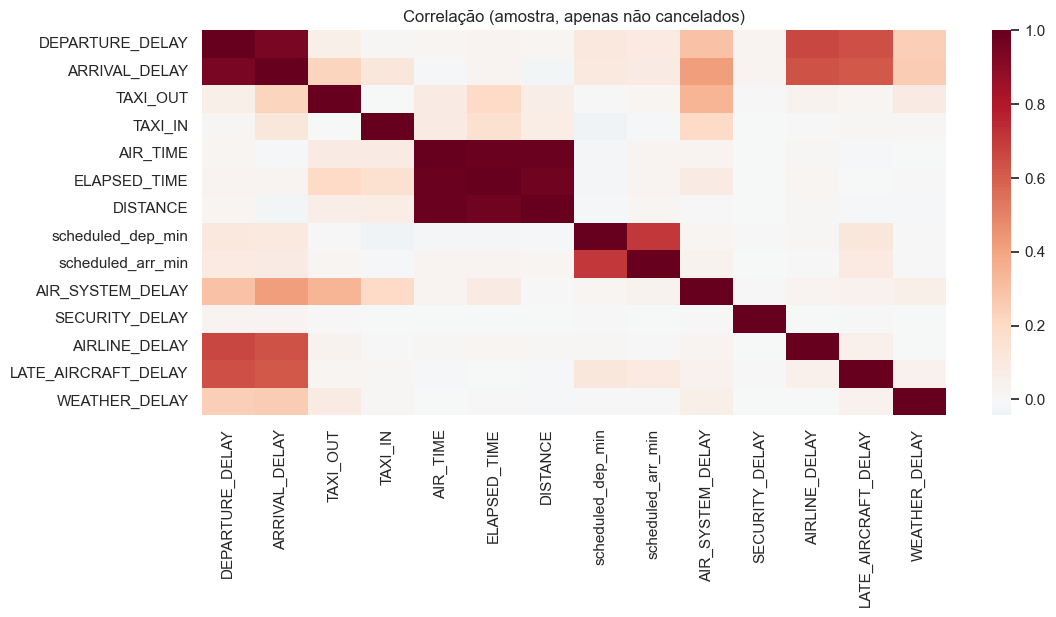

In [14]:
corr_cols = [
    c
    for c in [
        "DEPARTURE_DELAY",
        "ARRIVAL_DELAY",
        "TAXI_OUT",
        "TAXI_IN",
        "AIR_TIME",
        "ELAPSED_TIME",
        "DISTANCE",
        "scheduled_dep_min",
        "scheduled_arr_min",
        *[c for c in DELAY_CAUSE_COLS if c in active.columns],
    ]
    if c in active.columns
]

corr = active[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, cmap="RdBu_r", center=0)
plt.title("Correlação (amostra, apenas não cancelados)")
plt.show()

In [15]:
from collections import defaultdict

def aggregate_in_chunks(path: Path, chunksize: int = 400_000) -> dict[str, pd.DataFrame | int | float]:
    usecols = [
        "MONTH",
        "DAY_OF_WEEK",
        "AIRLINE",
        "CANCELLED",
        "DIVERTED",
        "ARRIVAL_DELAY",
        "DEPARTURE_DELAY",
        "SCHEDULED_DEPARTURE",
        "SCHEDULED_ARRIVAL",  # necessário para as features de horário
        "ORIGIN_AIRPORT",
        "DESTINATION_AIRPORT",
        "DISTANCE",
    ]

    flights = 0
    cancelled = 0

    # por airline
    n_by_airline = defaultdict(int)
    cancel_by_airline = defaultdict(int)
    sum_arr_delay_by_airline = defaultdict(float)
    cnt_arr_delay_by_airline = defaultdict(int)
    late15_by_airline = defaultdict(int)

    # por mês
    n_by_month = defaultdict(int)
    cancel_by_month = defaultdict(int)
    sum_arr_delay_by_month = defaultdict(float)
    cnt_arr_delay_by_month = defaultdict(int)

    # por hora programada
    n_by_hour = defaultdict(int)
    sum_arr_delay_by_hour = defaultdict(float)
    cnt_arr_delay_by_hour = defaultdict(int)

    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize):
        chunk = clean_flights(chunk)
        flights += len(chunk)
        if "CANCELLED" in chunk.columns:
            cancelled += int(chunk["CANCELLED"].sum())

        active = chunk[chunk["CANCELLED"] == 0]

        # airline
        for a, g in chunk.groupby("AIRLINE"):
            n_by_airline[a] += len(g)
            cancel_by_airline[a] += int(g["CANCELLED"].sum())

        for a, g in active.groupby("AIRLINE"):
            s = g["ARRIVAL_DELAY"].dropna()
            if len(s) > 0:
                sum_arr_delay_by_airline[a] += float(s.sum())
                cnt_arr_delay_by_airline[a] += int(s.shape[0])
                late15_by_airline[a] += int((s > 15).sum())

        # month
        for m, g in chunk.groupby("MONTH"):
            if pd.isna(m):
                continue
            n_by_month[int(m)] += len(g)
            cancel_by_month[int(m)] += int(g["CANCELLED"].sum())

        for m, g in active.groupby("MONTH"):
            if pd.isna(m):
                continue
            s = g["ARRIVAL_DELAY"].dropna()
            if len(s) > 0:
                sum_arr_delay_by_month[int(m)] += float(s.sum())
                cnt_arr_delay_by_month[int(m)] += int(s.shape[0])

        # hour
        if "scheduled_dep_hour" in active.columns:
            for h, g in active.dropna(subset=["scheduled_dep_hour"]).groupby("scheduled_dep_hour"):
                h = int(h)
                n_by_hour[h] += len(g)
                s = g["ARRIVAL_DELAY"].dropna()
                if len(s) > 0:
                    sum_arr_delay_by_hour[h] += float(s.sum())
                    cnt_arr_delay_by_hour[h] += int(s.shape[0])

    by_airline = pd.DataFrame(
        {
            "AIRLINE": list(n_by_airline.keys()),
            "flights": [n_by_airline[k] for k in n_by_airline.keys()],
            "cancel_rate": [cancel_by_airline[k] / n_by_airline[k] for k in n_by_airline.keys()],
            "mean_arr_delay": [
                (sum_arr_delay_by_airline[k] / cnt_arr_delay_by_airline[k]) if cnt_arr_delay_by_airline[k] else np.nan
                for k in n_by_airline.keys()
            ],
            "late15_rate": [
                (late15_by_airline[k] / cnt_arr_delay_by_airline[k]) if cnt_arr_delay_by_airline[k] else np.nan
                for k in n_by_airline.keys()
            ],
        }
    )

    by_month = pd.DataFrame(
        {
            "MONTH": sorted(n_by_month.keys()),
            "flights": [n_by_month[m] for m in sorted(n_by_month.keys())],
            "cancel_rate": [cancel_by_month[m] / n_by_month[m] for m in sorted(n_by_month.keys())],
            "mean_arr_delay": [
                (sum_arr_delay_by_month[m] / cnt_arr_delay_by_month[m]) if cnt_arr_delay_by_month[m] else np.nan
                for m in sorted(n_by_month.keys())
            ],
        }
    )

    by_hour = pd.DataFrame(
        {
            "scheduled_dep_hour": sorted(n_by_hour.keys()),
            "flights": [n_by_hour[h] for h in sorted(n_by_hour.keys())],
            "mean_arr_delay": [
                (sum_arr_delay_by_hour[h] / cnt_arr_delay_by_hour[h]) if cnt_arr_delay_by_hour[h] else np.nan
                for h in sorted(n_by_hour.keys())
            ],
        }
    )

    return {
        "n_rows": flights,
        "cancelled_%": (cancelled / flights * 100) if flights else np.nan,
        "by_airline": by_airline,
        "by_month": by_month,
        "by_hour": by_hour,
    }


agg = aggregate_in_chunks(FLIGHTS_PATH)
agg["n_rows"], agg["cancelled_%"]

(5819079, 1.5446430612129514)

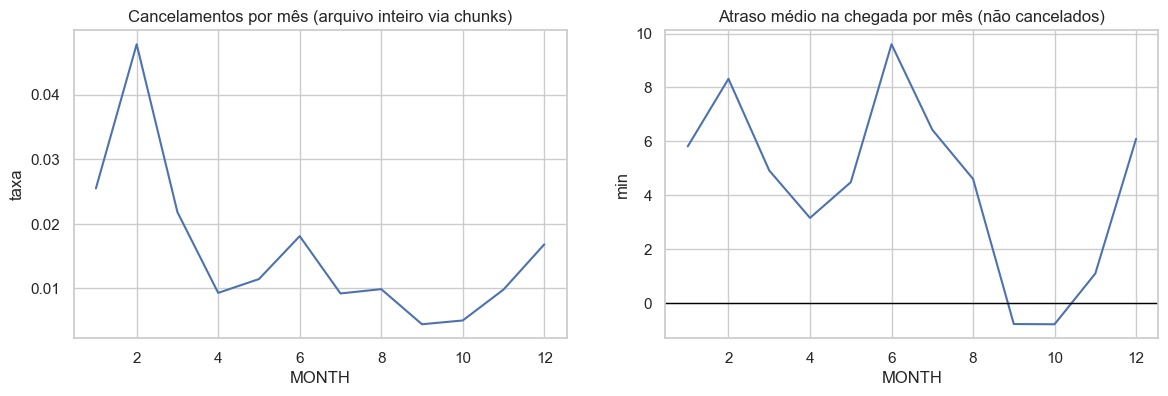

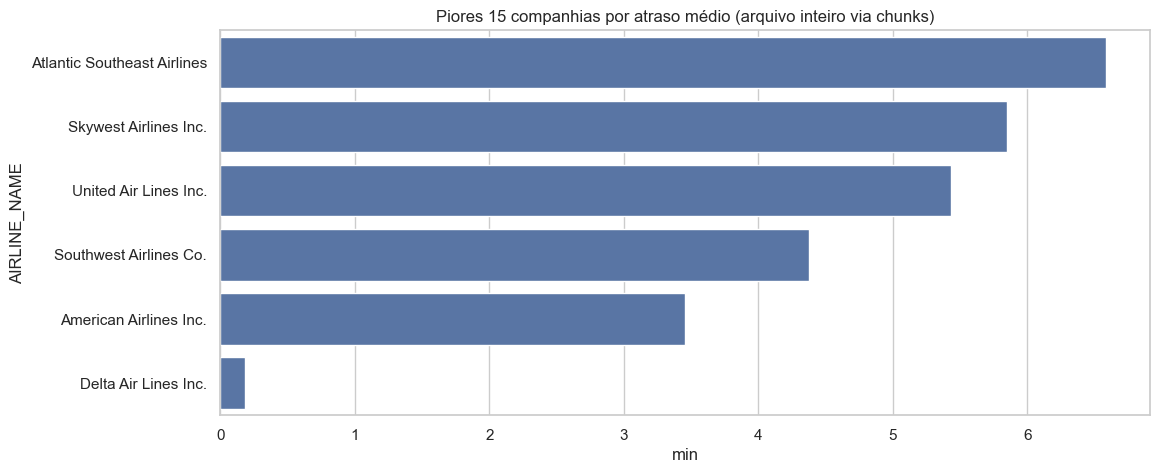

In [25]:
by_month = agg["by_month"].copy()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=by_month, x="MONTH", y="cancel_rate", ax=ax[0])
ax[0].set_title("Cancelamentos por mês (arquivo inteiro via chunks)")
ax[0].set_ylabel("taxa")

sns.lineplot(data=by_month, x="MONTH", y="mean_arr_delay", ax=ax[1])
ax[1].axhline(0, color="black", linewidth=1)
ax[1].set_title("Atraso médio na chegada por mês (não cancelados)")
ax[1].set_ylabel("min")

plt.show()

by_airline = agg["by_airline"].copy()
if airlines is not None and set(["IATA_CODE", "AIRLINE"]).issubset(airlines.columns):
    by_airline = by_airline.merge(
        airlines.rename(columns={"IATA_CODE": "AIRLINE", "AIRLINE": "AIRLINE_NAME"}),
        on="AIRLINE",
        how="left",
    )

# foca em empresas com volume relevante
by_airline = by_airline[by_airline["flights"] >= by_airline["flights"].quantile(0.6)].copy()
by_airline = by_airline.sort_values("mean_arr_delay", ascending=False)

ax = sns.barplot(
    data=by_airline.head(15),
    y=("AIRLINE_NAME" if "AIRLINE_NAME" in by_airline.columns else "AIRLINE"),
    x="mean_arr_delay",
)
ax.set_title("Piores 15 companhias por atraso médio (arquivo inteiro via chunks)")
ax.set_xlabel("min")
plt.show()